Omar Marmoush — Player Profile Report
AFCON 2023 | Egypt Campaign Analysis

Prepared by Abdelrhman Madian | Football Data Analyst

Analysis covers all 4 Egypt matches at AFCON 2023:
- Egypt vs Mozambique
- Egypt vs Ghana  
- Egypt vs Cape Verde Islands
- Egypt vs Congo DR

In [1]:
!pip install mplsoccer statsbombpy -q

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsbombpy import sb

competitions = sb.competitions()
print(competitions[['competition_id', 'season_id', 'competition_name', 'season_name']])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


    competition_id  season_id        competition_name season_name
0                9        281           1. Bundesliga   2023/2024
1                9         27           1. Bundesliga   2015/2016
2             1267        107  African Cup of Nations        2023
3               16          4        Champions League   2018/2019
4               16          1        Champions League   2017/2018
..             ...        ...                     ...         ...
70              35         75      UEFA Europa League   1988/1989
71              53        315       UEFA Women's Euro        2025
72              53        106       UEFA Women's Euro        2022
73              72        107       Women's World Cup        2023
74              72         30       Women's World Cup        2019

[75 rows x 4 columns]


In [2]:
# Load AFCON 2023 matches
afcon_matches = sb.matches(competition_id=1267, season_id=107)

# Filter Egypt matches
egypt_matches = afcon_matches[
    (afcon_matches['home_team'] == 'Egypt') |
    (afcon_matches['away_team'] == 'Egypt')
]
print(f"Egypt matches: {len(egypt_matches)}")
print(egypt_matches[['match_id', 'home_team', 'away_team', 'match_date']])

Egypt matches: 4
    match_id           home_team   away_team  match_date
14   3922240               Egypt    Congo DR  2024-01-28
16   3920396               Egypt       Ghana  2024-01-18
18   3920385               Egypt  Mozambique  2024-01-14
28   3920411  Cape Verde Islands       Egypt  2024-01-22


/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [3]:
# Load all Egypt match events
all_egypt_events = []

for match_id in egypt_matches['match_id']:
    try:
        events = sb.events(match_id=match_id)
        all_egypt_events.append(events)
    except:
        pass

all_egypt_events = pd.concat(all_egypt_events, ignore_index=True)
print(f"Total events loaded: {len(all_egypt_events)}")

# Find Marmoush in the data
marmoush_events = all_egypt_events[all_egypt_events['player'].str.contains('Marmoush', na=False)]
print(f"\nMarmoush total events: {len(marmoush_events)}")
print(marmoush_events['type'].value_counts())

/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Total events loaded: 13730

Marmoush total events: 372
type
Ball Receipt*      102
Carry               86
Pass                65
Pressure            37
Dribble             19
Ball Recovery       13
Foul Won            10
Shot                 9
Miscontrol           7
Duel                 5
Foul Committed       4
Block                3
Dispossessed         3
Dribbled Past        2
Interception         2
Substitution         2
Injury Stoppage      1
Clearance            1
50/50                1
Name: count, dtype: int64


Total shots: 9
Total goals: 2
Total xG: 1.48


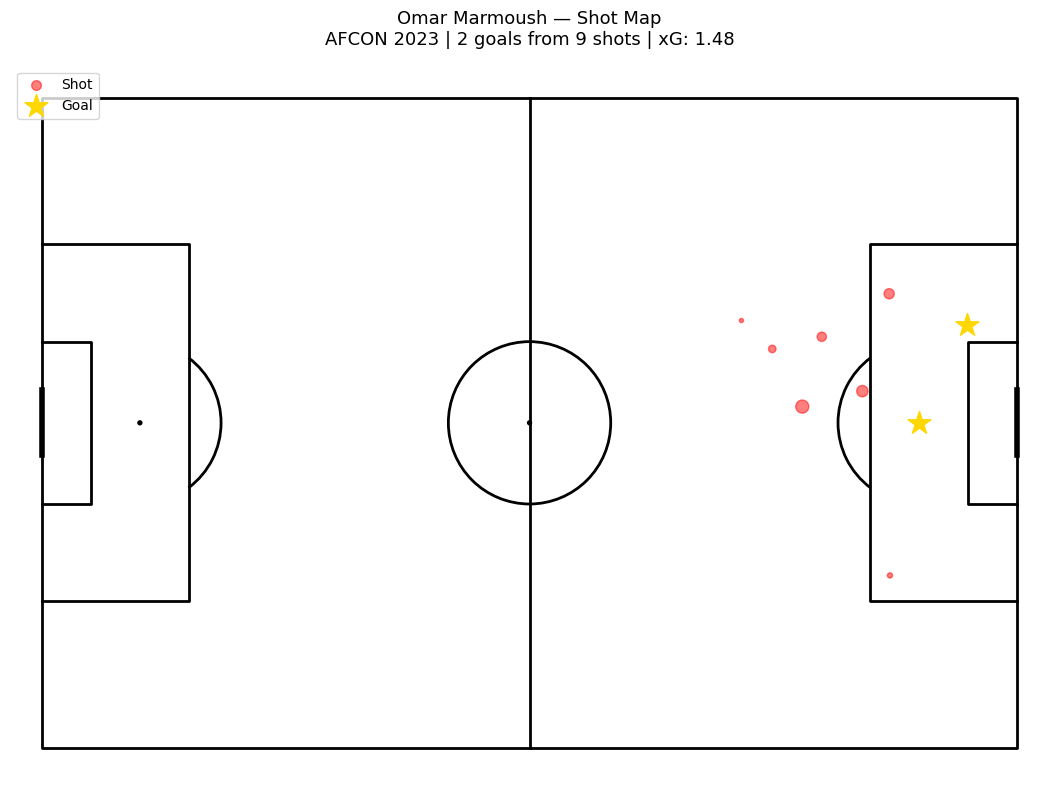

In [4]:
# Marmoush shot map
from mplsoccer import Pitch
marmoush_shots = marmoush_events[marmoush_events['type'] == 'Shot'].copy()
marmoush_shots['x'] = marmoush_shots['location'].apply(lambda loc: loc[0])
marmoush_shots['y'] = marmoush_shots['location'].apply(lambda loc: loc[1])

goals = marmoush_shots[marmoush_shots['shot_outcome'] == 'Goal']
no_goals = marmoush_shots[marmoush_shots['shot_outcome'] != 'Goal']

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(no_goals['x'], no_goals['y'], ax=ax,
              s=no_goals['shot_statsbomb_xg'] * 1500,
              color='red', alpha=0.5, label='Shot')
pitch.scatter(goals['x'], goals['y'], ax=ax,
              s=300, color='gold', marker='*', label='Goal')

total_xg = marmoush_shots['shot_statsbomb_xg'].sum()
print(f"Total shots: {len(marmoush_shots)}")
print(f"Total goals: {len(goals)}")
print(f"Total xG: {total_xg:.2f}")

ax.set_title(f'Omar Marmoush — Shot Map\nAFCON 2023 | {len(goals)} goals from {len(marmoush_shots)} shots | xG: {total_xg:.2f}',
             fontsize=13, pad=15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

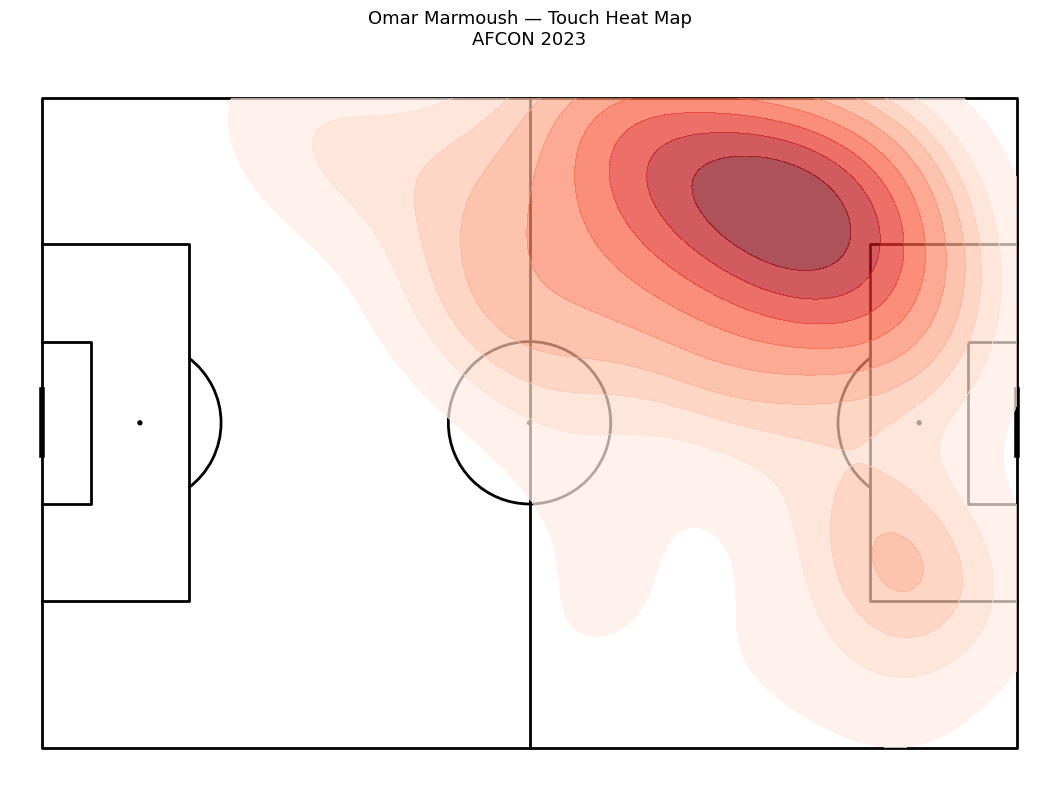

In [5]:
# Marmoush heat map - all touches
marmoush_touches = marmoush_events[marmoush_events['type'] == 'Ball Receipt*'].copy()
marmoush_touches['x'] = marmoush_touches['location'].apply(lambda loc: loc[0])
marmoush_touches['y'] = marmoush_touches['location'].apply(lambda loc: loc[1])

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))

pitch.kdeplot(marmoush_touches['x'], marmoush_touches['y'], ax=ax,
              fill=True, cmap='Reds', levels=10, alpha=0.7)

ax.set_title('Omar Marmoush — Touch Heat Map\nAFCON 2023', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

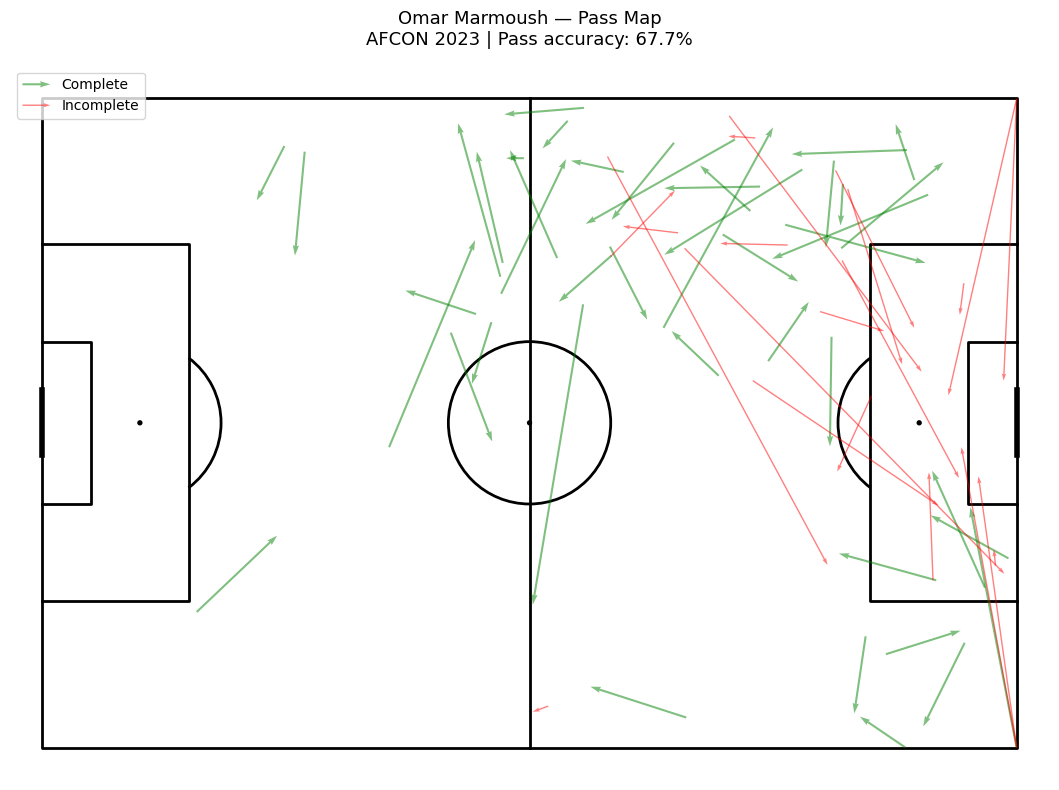

In [6]:
# Marmoush passing map
marmoush_passes = marmoush_events[marmoush_events['type'] == 'Pass'].copy()
marmoush_passes['x'] = marmoush_passes['location'].apply(lambda loc: loc[0])
marmoush_passes['y'] = marmoush_passes['location'].apply(lambda loc: loc[1])
marmoush_passes['end_x'] = marmoush_passes['pass_end_location'].apply(lambda loc: loc[0])
marmoush_passes['end_y'] = marmoush_passes['pass_end_location'].apply(lambda loc: loc[1])

complete = marmoush_passes[marmoush_passes['pass_outcome'].isna()]
incomplete = marmoush_passes[marmoush_passes['pass_outcome'].notna()]

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))

pitch.arrows(complete['x'], complete['y'], complete['end_x'], complete['end_y'],
             ax=ax, color='green', alpha=0.5, width=1.5, label='Complete')
pitch.arrows(incomplete['x'], incomplete['y'], incomplete['end_x'], incomplete['end_y'],
             ax=ax, color='red', alpha=0.5, width=1, label='Incomplete')

accuracy = len(complete) / len(marmoush_passes) * 100
ax.set_title(f'Omar Marmoush — Pass Map\nAFCON 2023 | Pass accuracy: {accuracy:.1f}%',
             fontsize=13, pad=15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

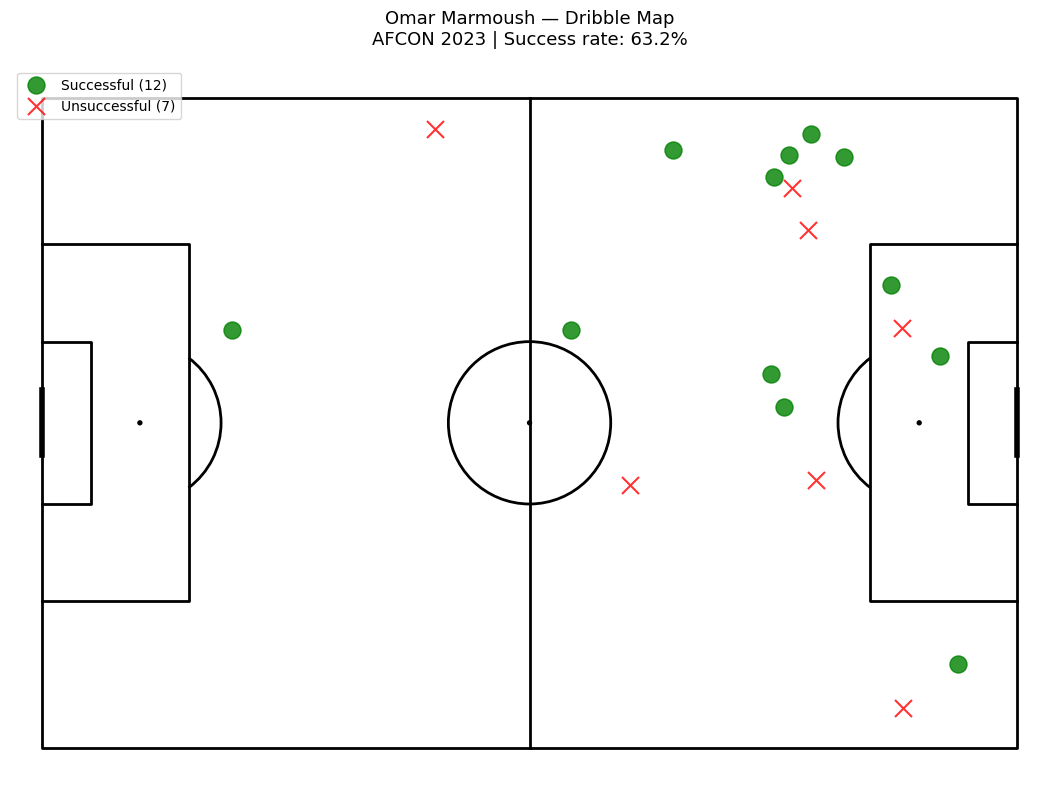

In [7]:
# Marmoush dribble map
marmoush_dribbles = marmoush_events[marmoush_events['type'] == 'Dribble'].copy()
marmoush_dribbles['x'] = marmoush_dribbles['location'].apply(lambda loc: loc[0])
marmoush_dribbles['y'] = marmoush_dribbles['location'].apply(lambda loc: loc[1])

successful = marmoush_dribbles[marmoush_dribbles['dribble_outcome'] == 'Complete']
unsuccessful = marmoush_dribbles[marmoush_dribbles['dribble_outcome'] != 'Complete']

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(12, 8))

pitch.scatter(successful['x'], successful['y'], ax=ax,
              s=150, color='green', alpha=0.8, label=f'Successful ({len(successful)})')
pitch.scatter(unsuccessful['x'], unsuccessful['y'], ax=ax,
              s=150, color='red', alpha=0.8, marker='x', label=f'Unsuccessful ({len(unsuccessful)})')

success_rate = len(successful) / len(marmoush_dribbles) * 100
ax.set_title(f'Omar Marmoush — Dribble Map\nAFCON 2023 | Success rate: {success_rate:.1f}%',
             fontsize=13, pad=15)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

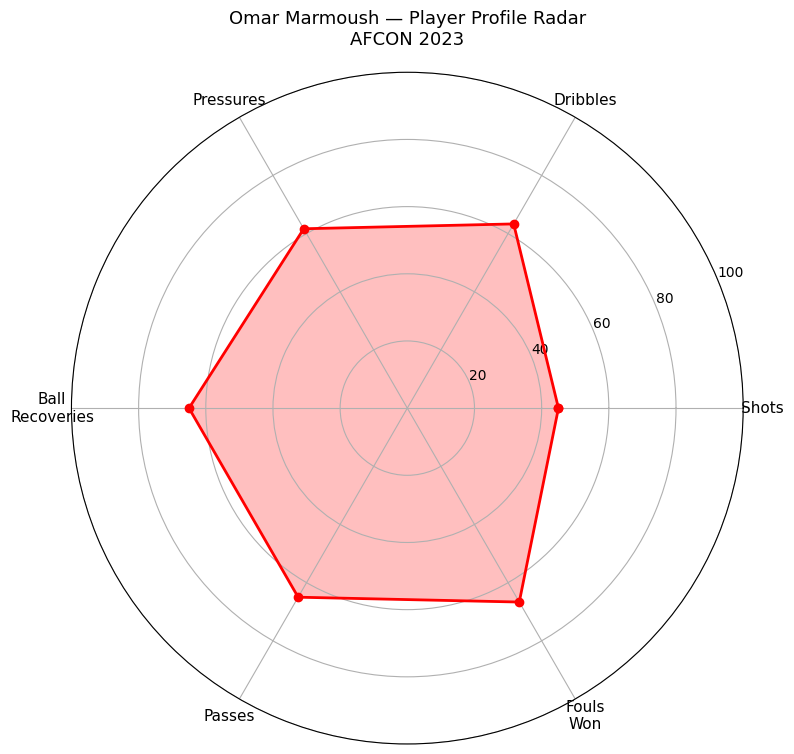

In [8]:
# Marmoush radar chart
categories = ['Shots', 'Dribbles', 'Pressures', 'Ball\nRecoveries', 'Passes', 'Fouls\nWon']

values = [
    len(marmoush_events[marmoush_events['type'] == 'Shot']),
    len(marmoush_events[marmoush_events['type'] == 'Dribble']),
    len(marmoush_events[marmoush_events['type'] == 'Pressure']),
    len(marmoush_events[marmoush_events['type'] == 'Ball Recovery']),
    len(marmoush_events[marmoush_events['type'] == 'Pass']),
    len(marmoush_events[marmoush_events['type'] == 'Foul Won']),
]

# Normalize to 0-100
max_values = [20, 30, 60, 20, 100, 15]
normalized = [min(v/m*100, 100) for v, m in zip(values, max_values)]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
normalized += normalized[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, normalized, 'o-', linewidth=2, color='red')
ax.fill(angles, normalized, alpha=0.25, color='red')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Omar Marmoush — Player Profile Radar\nAFCON 2023', fontsize=13, pad=20)

plt.tight_layout()
plt.show()

AFCON 2023, played in Ivory Coast from January 2024, is the perfect competition to analyze Omar Marmoush — it came at the start of his remarkable breakout season at Eintracht Frankfurt. Marmoush played all 4 matches of Egypt's campaign. His shot map shows 9 shots, 2 goals — one from open play and one from the penalty shootout — with a total xG of 1.48. He frequently attempts shots from outside the box, which is a trademark of his game. His heat map confirms he operated almost entirely on the left wing, concentrating near the box edge — consistently cutting inside to shoot, which is where he is most dangerous. His pass map shows 67.7% accuracy, with most completed passes being short combinations on the wing and in midfield, while almost all his failed passes were ambitious long balls into the box. His dribble map shows 19 attempts across 4 matches with a 63.2% success rate — 8 on the left wing, 5 in the middle, and 3 inside the box, confirming he is willing to take players on in every zone of the pitch not just in safe wide areas. His radar chart shows dribbles, pressures, ball recoveries, fouls won, and passes all above 60 — only shots sit around 40, which is misleading given he converted 2 from 9 for a 22% conversion rate. This was not a perfect tournament for Marmoush, but given that Egypt relied heavily on Salah as their main creative force, Marmoush delivered more than his share — working hard, taking risks, and proving his quality on the biggest African stage just before his explosive Bundesliga season.